In [1]:
pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 7.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136818 sha256=4872e33fc477e82d2602de0683ab9bf2db120844a548d15f69dabc34f37a7d6a
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def algoritmo_bernstein_vazirani(cadena):
    n = len(cadena)

    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()

    cadena_invertida = cadena[::-1]

    for i in range(n):
        if cadena_invertida[i] == '1':
            qc.cx(i, n)

    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

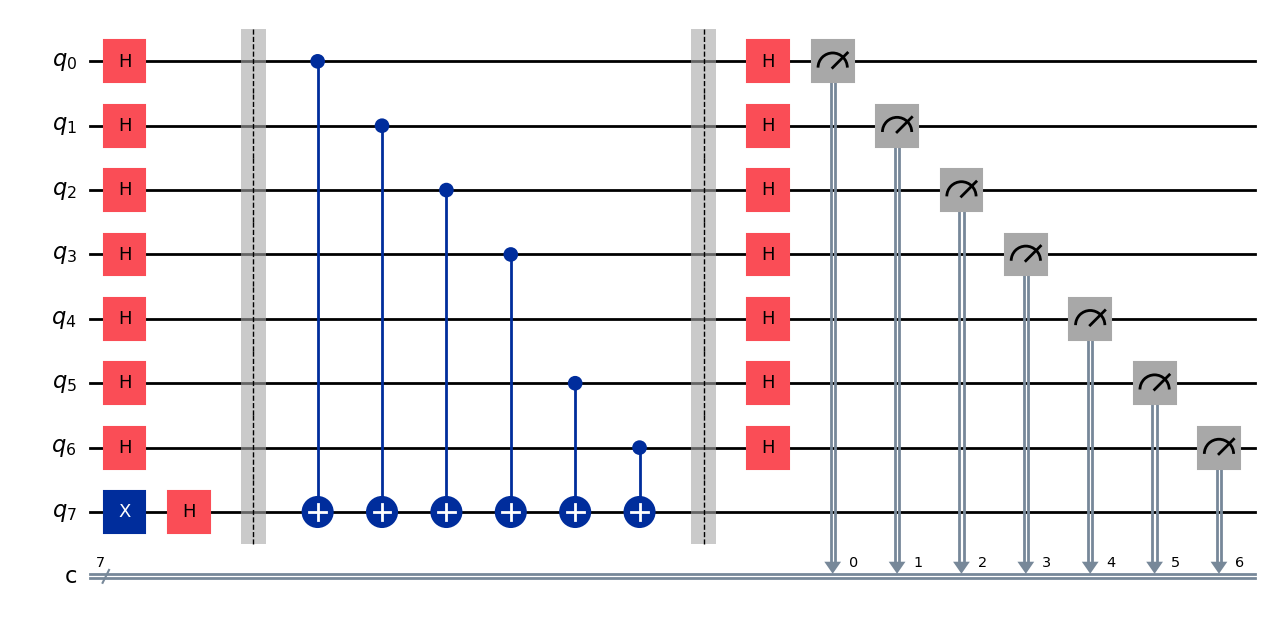

La cadena secreta original era: 1101111
El resultado medido por el circuito es: 1101111


In [19]:
# Variable de entrada
cadena = "1101111"

# Genero el circuto
circuito_bv = algoritmo_bernstein_vazirani(cadena)

# Dibujo el circuito generado
display(circuito_bv.draw('mpl'))

# Simulo del circuito
resultado = AerSimulator().run(circuito_bv, shots=8).result()

# Muestro los resultados
conteos = resultado.get_counts()
print(f"La cadena secreta original era: {cadena}")
print(f"El resultado medido por el circuito es: {list(conteos)[0]}")